In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [50]:
df = pd.read_csv("traffic.csv")
print("Data Loaded Successfully!\n")

Data Loaded Successfully!



In [51]:
print("First 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

First 5 rows:
              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None

Summary Statistics:
           Junction      Vehicles            ID
count  48120.000000  48120.000000  4.812000e+04
mean       2.180549     22.791334  2.016330e+10
std        0.966955     20.750063  5.944854e+06
min        1.000000      1.0000

In [52]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


In [53]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day
df['Month'] = df['DateTime'].dt.month

df.head()

,DateTime,Junction,Vehicles,ID,Hour,Day,Month
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11


In [54]:
print(df.describe())

                            DateTime      Junction      Vehicles  \
count                          48120  48120.000000  48120.000000   
mean   2016-09-19 06:03:56.109725696      2.180549     22.791334   
min              2015-11-01 00:00:00      1.000000      1.000000   
25%              2016-04-16 01:45:00      1.000000      9.000000   
50%              2016-09-30 03:30:00      2.000000     15.000000   
75%              2017-02-25 16:00:00      3.000000     29.000000   
max              2017-06-30 23:00:00      4.000000    180.000000   
std                              NaN      0.966955     20.750063   

                 ID          Hour           Day         Month  
count  4.812000e+04  48120.000000  48120.000000  48120.000000  
mean   2.016330e+10     11.500000     15.700748      5.884289  
min    2.015110e+10      0.000000      1.000000      1.000000  
25%    2.016042e+10      5.750000      8.000000      3.000000  
50%    2.016093e+10     11.500000     16.000000      5.000000  
75%

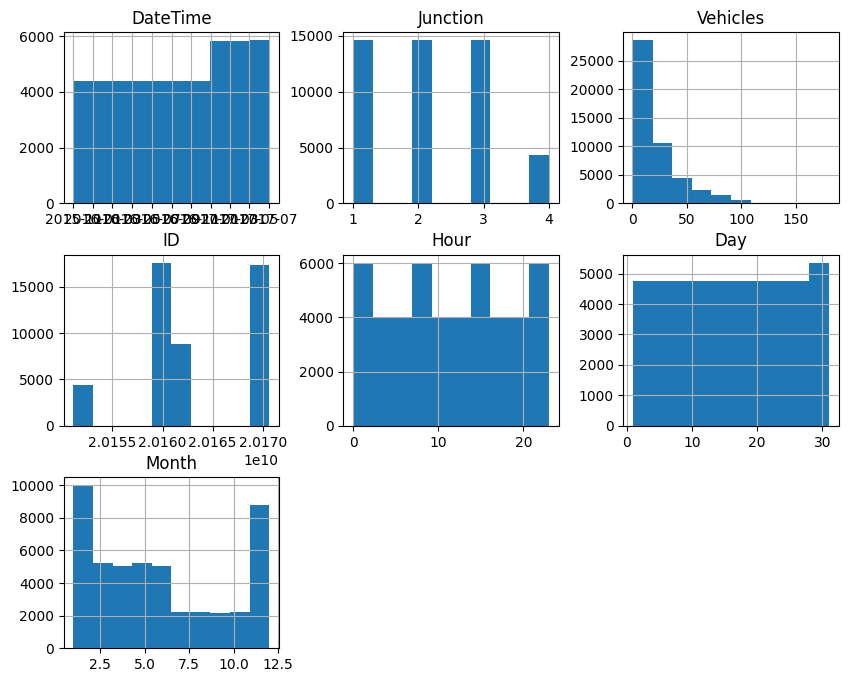

In [55]:
df.hist(figsize=(10,8))
plt.show()

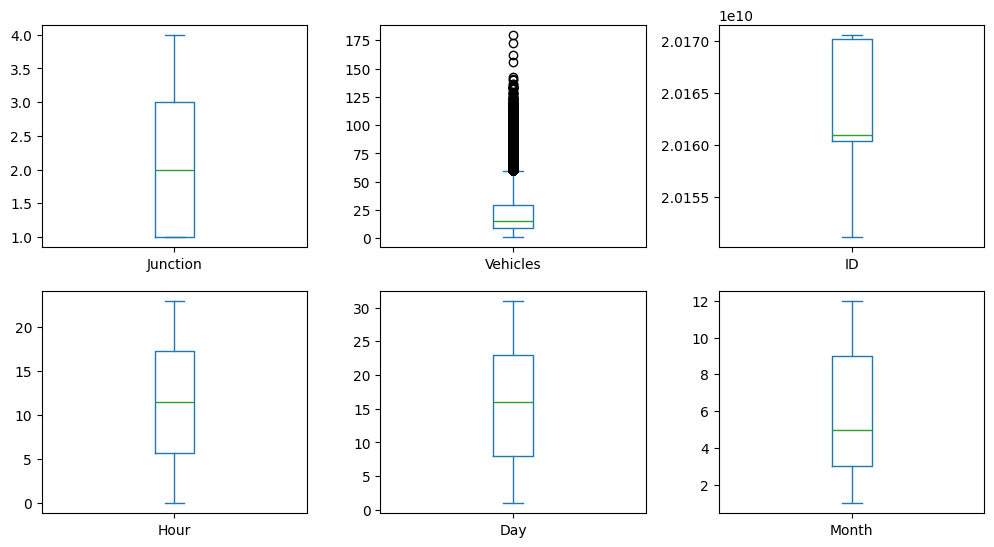

In [56]:
numeric_cols = df.select_dtypes(include='number')

numeric_cols.plot(kind='box', subplots=True, layout=(3,3), figsize=(10,8))

plt.tight_layout()
plt.show()

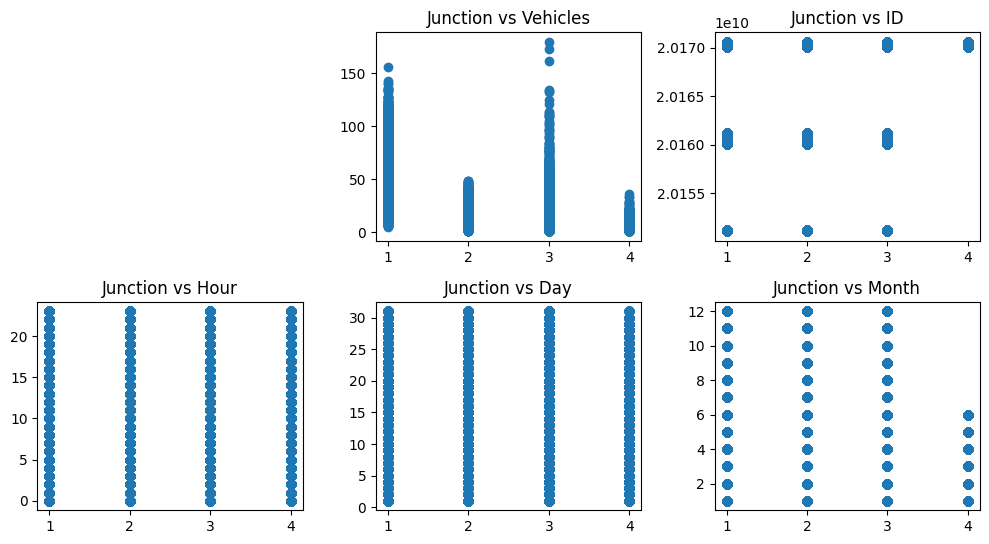

In [57]:
numeric_cols = df.select_dtypes(include='number')
cols = numeric_cols.columns
plt.figure(figsize=(10,8))
for i, col in enumerate(cols):
    if col != cols[0]:  
        plt.subplot(3,3,i+1)
        plt.scatter(df[cols[0]], df[col])
        plt.title(f"{cols[0]} vs {col}")
plt.tight_layout()
plt.show()

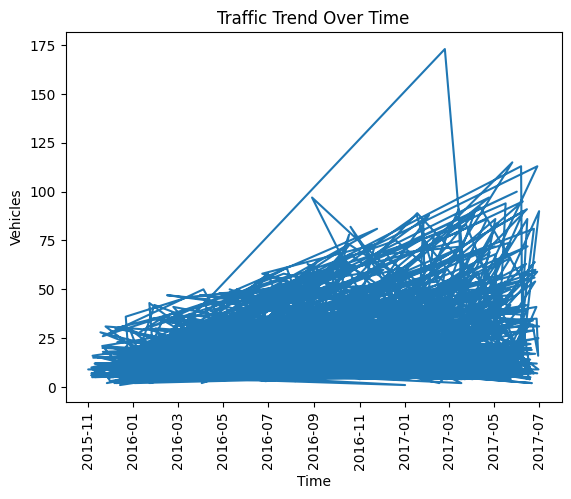

In [58]:
sample_df = df.sample(1000, random_state=42)
plt.figure()
plt.plot(sample_df['DateTime'], sample_df['Vehicles'])
plt.title("Traffic Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Vehicles")
plt.xticks(rotation=90)
plt.show()

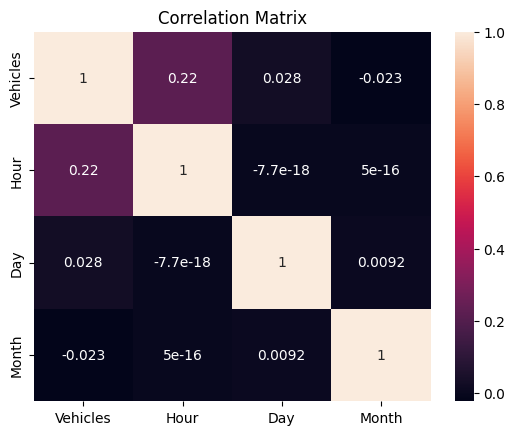

In [59]:
plt.figure()
sns.heatmap(df[['Vehicles','Hour','Day','Month']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
sns.pairplot(df)
plt.show()

In [ ]:
X = df[['Vehicles', 'Hour']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['Cluster'])
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X')

plt.xlabel("Vehicles (Scaled)")
plt.ylabel("Hour (Scaled)")
plt.title("K-Means Clusters with Centroids")
plt.show()

In [48]:
df.groupby('Cluster').mean()

KeyError: 'Cluster'

In [45]:
print("Cluster 0 = Low traffic")
print("Cluster 1 = Medium traffic")
print("Cluster 2 = High traffic")

Cluster 0 = Low traffic
Cluster 1 = Medium traffic
Cluster 2 = High traffic
